Directorio: /home/coders/Escritorio/emausoft-analytics
Shape clientes: (100, 6)
   cliente_id          nombre             ciudad         pais  \
0           1   Maya Gauthier         St. George       Canada   
1           2     Toivo Lauri           Kumlinge      Finland   
2           3     Orhun Obdam         Luttenberg  Netherlands   
3           4  Ryder Bélanger         Enterprise       Canada   
4           5   Hossam Geilen  Tytsjerksteradiel  Netherlands   

                        email  genero  
0   maya.gauthier@example.com  female  
1     toivo.lauri@example.com    male  
2     orhun.obdam@example.com    male  
3  ryder.belanger@example.com    male  
4   hossam.geilen@example.com    male  

Nulos:
cliente_id    0
nombre        0
ciudad        0
pais          0
email         0
genero        0
dtype: int64

Tipos:
cliente_id    int64
nombre          str
ciudad          str
pais            str
email           str
genero          str
dtype: object


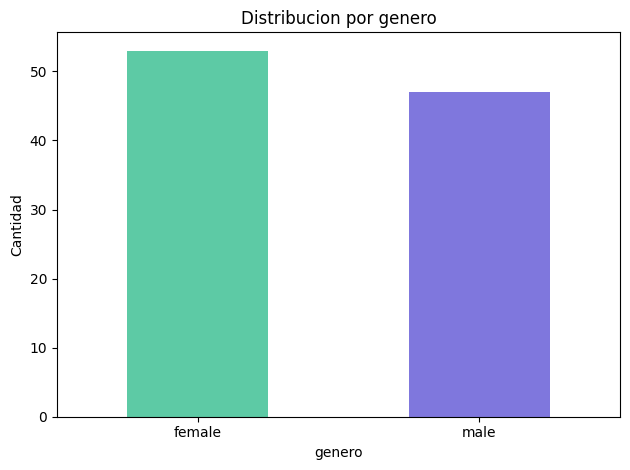

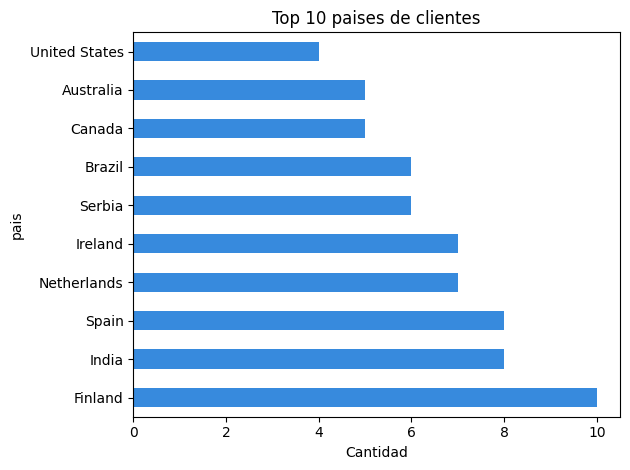


Ventas con cliente_id: 2823
Ventas sin cliente_id: 0
Guardado: data/interim/ventas_con_cliente.csv


In [1]:
import os, sys, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path('/home/coders/Escritorio/emausoft-analytics')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print(f'Directorio: {os.getcwd()}')

from src.ingestion.fetch_clientes import fetch_clientes, normalizar, asignar_clientes

# Cargar clientes

df_clientes = pd.read_csv(ROOT / 'data/interim/clientes.csv')
print(f'Shape clientes: {df_clientes.shape}')
print(df_clientes.head())

# Analisis exploratorio

print('\nNulos:')
print(df_clientes.isnull().sum())
print('\nTipos:')
print(df_clientes.dtypes)

# Distribucion por genero

df_clientes['genero'].value_counts().plot(kind='bar', color=['#5DCAA5','#7F77DD'])
plt.title('Distribucion por genero')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Distribucion por pais

df_clientes['pais'].value_counts().head(10).plot(kind='barh', color='#378ADD')
plt.title('Top 10 paises de clientes')
plt.xlabel('Cantidad')
plt.tight_layout()
plt.show()

# Asignar cliente_id a las ventas

df_ventas = pd.read_csv(ROOT / 'data/raw/sales_data_sample.csv', encoding='latin-1')
df_ventas = asignar_clientes(df_ventas, df_clientes)

print(f'\nVentas con cliente_id: {df_ventas["cliente_id"].notna().sum()}')
print(f'Ventas sin cliente_id: {df_ventas["cliente_id"].isna().sum()}')

# Guardar ventas enriquecidas con cliente_id

df_ventas.to_csv(ROOT / 'data/interim/ventas_con_cliente.csv', index=False)
print('Guardado: data/interim/ventas_con_cliente.csv')